## Extension Analysis Work (on-going)

In [1]:
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import root_mean_squared_error
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
def joules_to_kwh(joules):
    return float(joules) / 3600000

def load_philipp_data(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/wf_data.csv') as file:
            stripped_lines = [line.rstrip().split(',') for line in file.readlines()]
            data = stripped_lines[1:]

        pkg = data[0][11]
        dram = data[0][12]
        total = data[0][13]

        processed[run] = {}
        processed[run]['pkg'] = joules_to_kwh(pkg)
        processed[run]['dram'] = joules_to_kwh(dram)
        processed[run]['total'] = joules_to_kwh(total)
    
    return processed


def load_data_totals(cluster, workflow, runs):
    processed = {}

    for run in range(1, runs+1):
        proc_data = pd.read_csv(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv', header=0)
        processed[run] = {}
        processed[run]['read'] = proc_data['read_bytes'].sum() / 1073741824  # convert from B to GiB
        processed[run]['write'] = proc_data['write_bytes'].sum() / 1073741824  # convert from B to GiB

    return processed


def load_philipp_total_energy(cluster, workflow, runs):
    processed = {}
        
    for run in range(1, runs+1):
        with open(f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/task_data.md') as file:
            lines = [line.strip() for line in file.readlines()]

        final = lines[-1].split(': ')[1][:-6]

        processed[run] = {}
        processed[run]['pkg'] = None
        processed[run]['dram'] = None
        processed[run]['total'] = joules_to_kwh(final)
    
    return processed

In [3]:
# Functions to parse rapl data
def load_workflow_rapl_readings(cluster, workflow):
    with open(f'nxf-experiments/{cluster}-cluster/{workflow}-runs.csv', 'r') as file:
        data = [line.strip().split(',') for line in file.readlines()]
    
    return data[1:]

gu_socket = {'rnaseq': 'both', 'chipseq': 'both', 'nanoseq': 'both', 'atacseq': 'both'}

def process_rapl_data(data, gu=False, wf=''):
    processed = {}
    run = 1

    for row in data:
        if gu:
            active_pkg_1 = float(row[7])
            active_pkg_2 = float(row[16])
            active_dram_1 = float(row[8])
            active_dram_2 = float(row[17])
            rapl_pkg = active_pkg_1 + active_pkg_2
            rapl_mem = active_dram_1 + active_dram_2
            rapl_total = rapl_pkg + rapl_mem
        else:
            active_pkg = float(row[7])
            rapl_pkg = active_pkg
            active_dram = float(row[8])
            rapl_mem = active_dram
            rapl_total = rapl_pkg + rapl_mem

        processed[run] = {}
        processed[run]['pkg'] = rapl_pkg
        processed[run]['dram'] = rapl_mem
        processed[run]['total'] = rapl_total
        run += 1

    return processed

def process_airflow_rapl_data(data):
    processed = {}
    run = 1

    for row in data:
        pkg = float(row[4])
        dram = float(row[5])
        rapl_total = pkg + dram

        processed[run] = {}
        processed[run]['pkg'] = pkg
        processed[run]['dram'] = dram
        processed[run]['total'] = rapl_total
        run += 1

    return processed

In [4]:
# Airflow
def load_airflow_rapl_readings(experiment):
    with open(f'aflow-experiments/{experiment}-runs.csv', 'r') as file:
        data = [line.strip().split(',') for line in file.readlines()]
    return data[1:]

In [5]:
# Functions to parse ichnos data
def load_ichnos_summary_file(summary_file):
    with open(summary_file, 'r') as file:
        raw = [line.strip() for line in file.readlines()]

    cpu = float(raw[8].split(':')[1].strip()[:-3])
    task_mem = float(raw[10].split(':')[1].strip()[:-3])
    node_mem = float(raw[16].split(':')[1].strip()[:-3])
    cpu_static = float(raw[7].split(':')[1].strip()[:-3])

    return (cpu, task_mem, node_mem, cpu_static)

def load_ichnos_data(cluster, workflow, runs, strategy, ci):
    workflow_path = f'nxf-experiments/{cluster}-cluster/{workflow}/ichnos'
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'{workflow_path}/{cluster}-{workflow}-{run}-{ci}-{strategy}-summary.txt')
        data[run]['pkg'] = cpu
        data[run]['mem_dyn'] = task_mem
        data[run]['mem_stat'] = node_mem 
        data[run]['total'] = cpu + task_mem
        data[run]['pkg_stat'] = cpu_stat

    return data

def load_ichnos_summary_ci(cluster, workflow, runs, strategy, ci):
    workflow_path = f'nxf-experiments/{cluster}-cluster/{workflow}/ichnos'
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        summary_file = f'{workflow_path}/{cluster}-{workflow}-{run}-{ci}-{strategy}-summary.txt'
        with open(summary_file, 'r') as file:
            raw = [line.strip() for line in file.readlines()]

        cpu = float(raw[8].split(':')[1].strip()[:-3])
        task_mem = float(raw[10].split(':')[1].strip()[:-3])
        node_mem = float(raw[16].split(':')[1].strip()[:-3])
        cpu_static = float(raw[7].split(':')[1].strip()[:-3])
        op_ems = float(raw[12].split(':')[1].strip()[:-5])
        emb_ems = float(raw[13].split(':')[1].strip()[:-5])
        data[run]['pkg'] = cpu
        data[run]['mem_dyn'] = task_mem
        data[run]['mem_stat'] = node_mem 
        data[run]['total'] = cpu + task_mem
        data[run]['op_ems'] = op_ems
        data[run]['emb_ems'] = emb_ems

    return data

def load_ichnos_land_water_use(cluster, workflow, runs, strategy, ci):
    data = {}

    for run in range(1, runs + 1):
        data[run] = {}
        summary_file = f'nxf-experiments/env-use-case/{cluster}-{workflow}-{run}-{ci}-{strategy}-summary.txt'
        with open(summary_file, 'r') as file:
            raw = [line.strip() for line in file.readlines()]

        water_use = float(raw[15].split(':')[1].strip()[:-1])
        land_use = float(raw[16].split(':')[1].strip()[:-3])
        data[run]['land'] = land_use
        data[run]['water'] = water_use 

    return data

In [6]:
# Generic functions
def get_error(experimental, actual):
    return round((abs(experimental - actual) / actual) * 100, 2)

def get_error_dir(experimental, actual):
    return round(((experimental - actual) / actual) * 100, 2)

In [7]:
def load_nxf_trace(cluster, workflow, run, print=False):
    filepath = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/trace.csv'
    nxf_trace = pd.read_csv(filepath, header=0)
    start_ms = min(nxf_trace['start'])
    end_ms = max(nxf_trace['complete'])
    runtime = (end_ms - start_ms) / 1000 / 60  # mins
    start_day = datetime.fromtimestamp(start_ms / 1000).strftime('%Y-%m-%d')
    end_day = datetime.fromtimestamp(end_ms / 1000).strftime('%Y-%m-%d')
    nxf_trace['memory'] /= 1073741824

    if print:
        print(f'{cluster} {workflow} {run} took {runtime:.0f}m on {start_day} to {end_day}')

    return (nxf_trace, runtime)

In [8]:
def plot_task_length_fig(vals, workflow):
    plt.figure(figsize=(6,2))
    plt.violinplot(vals['realtime'] / 1000 / 60, vert=False, showmedians=True, showextrema=True)
    plt.title(workflow)
    plt.xlabel('time (m)')
    plt.xlim(0,60)
    plt.show()

In [9]:
def explore_workflow(wf, wf_df, time, node_mem, run):
    avg_task_cpu_usage = np.median(wf_df['%cpu'])
    avg_task_runtime = np.median(wf_df['realtime'] / 1000)

    print(f'[{wf}]')
    print(f'no. tasks {len(wf_df)}, runtime {time:.0f}m, task {avg_task_runtime:.0f}s, cpu% {avg_task_cpu_usage:.1f}%')
    print(f'cpu [i: {run['ichnos_pkg']}, r: {run['rapl_pkg']}, e: {run['err_pkg']}]')
    print(f'mem [i: {run['ichnos_task_mem']}, r: {run['rapl_mem']}, e: {run['err_mem']}]')

In [10]:
def report_memory_utilisation(wf_df, node_mem, cluster, workflow, run):
    interval = 5 * 1000  # 5s intervals
    tasks_by_node = wf_df.groupby('hostname')
    utilisation_split = {}

    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/{cluster}-cluster/{workflow}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        earliest = group_df['start'].min()
        latest = group_df['complete'].max()
        bins = np.arange(earliest, latest + interval, interval)
        bin_ends = bins + interval

        in_active_period = np.any(
            (bins[:, np.newaxis] < periods_df['end_ms'].values[np.newaxis, :]) &
            (bin_ends[:, np.newaxis] > periods_df['start_ms'].values[np.newaxis, :]),
            axis=1
        )
        filtered_bins = bins[in_active_period]
        filtered_bin_ends = bin_ends[in_active_period]

        if len(filtered_bins) == 0:
            print(f"Warning: no bins fall within active periods for node {node}, skipping.")
            continue

        active = (
            (group_df['start'].values[np.newaxis, :] < filtered_bin_ends[:, np.newaxis]) &
            (group_df['complete'].values[np.newaxis, :] > filtered_bins[:, np.newaxis])
        )

        memory = group_df['memory'].values
        usage_over_time = np.round(active @ memory / node_mem) * 100

        total = len(usage_over_time)
        vals, counts = np.unique(usage_over_time, return_counts=True)

        low_mask = vals < 10
        node_low_bins = int(counts[low_mask].sum())
        node_high_bins = int(counts[~low_mask].sum())

        utilisation_split[node] = {
            'low_pct':  round(node_low_bins / total * 100, 1),
            'high_pct': round(node_high_bins / total * 100, 1),
            'low_secs':  node_low_bins * 5,
            'high_secs': node_high_bins * 5,
        }

    return utilisation_split

In [11]:
def analyse_workflow(wf, wf_df, time, node_mem, node_cpus, wf_run):
    explore_workflow(wf, wf_df, time, node_mem, wf_run)
    plot_task_length_fig(wf_df, wf)

In [12]:
def get_val(raw_str):
    return float(raw_str.split(':')[1].strip())

def load_aws_weh_rapl(workflow, runs):
    rapl_data = {}

    for run in range(1, runs + 1):
        filepath = f'nxf-experiments/aws-cluster/{workflow}/{run}/weh-summary.txt'
        with open(filepath, 'r') as f:
            raw = f.readlines()

        rapl_cpu = get_val(raw[40])
        rapl_mem = get_val(raw[41])
        rapl_total = get_val(raw[42])

        rapl_data[run] = {'pkg': rapl_cpu, 'dram': rapl_mem, 'total': rapl_total}

    return rapl_data

In [13]:
# load all workflow rapl and ichnos data
rapl_data = {'hu': {}, 'gu': {}, 'aws': {}}
rapl_data['hu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rnaseq'), False, 'rnaseq')
rapl_data['hu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'chipseq'), False, 'chipseq')
rapl_data['hu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'atacseq'), False, 'atacseq')
rapl_data['hu']['rangeland'] = process_rapl_data(load_workflow_rapl_readings('hu', 'rangeland'), False, 'rangeland')
rapl_data['hu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('hu', 'nanoseq'), False, 'nanoseq')
rapl_data['hu']['sarek'] = process_rapl_data(load_workflow_rapl_readings('hu', 'sarek'), False, 'sarek')

rapl_data['gu']['atacseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'atacseq'), True, 'atacseq')
rapl_data['gu']['chipseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'chipseq'), True, 'chipseq')
rapl_data['gu']['nanoseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'nanoseq'), True, 'nanoseq')
rapl_data['gu']['rnaseq'] = process_rapl_data(load_workflow_rapl_readings('gu', 'rnaseq'), True, 'rnaseq')

ichnos_data = {'hu': {}, 'gu': {}, 'aws': {}}
ichnos_data['hu']['rnaseq'] = load_ichnos_data('hu', 'rnaseq', 3, 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['chipseq'] = load_ichnos_data('hu', 'chipseq', 3, 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['atacseq'] = load_ichnos_data('hu', 'atacseq', 3, 'performance_linear', 'de-2026-02-20-2026-02-24')
ichnos_data['hu']['rangeland'] = load_ichnos_data('hu', 'rangeland', 3, 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data['hu']['nanoseq'] = load_ichnos_data('hu', 'nanoseq', 3, 'performance_linear', 'de-2026-03-05-2026-03-07')
ichnos_data['hu']['sarek'] = load_ichnos_data('hu', 'sarek', 3, 'schedutil_linear', 'de-2026-02-07-2026-02-09')

ichnos_data['gu']['rnaseq'] = load_ichnos_data('gu', 'rnaseq', 3, 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['atacseq'] = load_ichnos_data('gu', 'atacseq', 3, 'ondemand_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data['gu']['chipseq'] = load_ichnos_data('gu', 'chipseq', 3, 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data['gu']['nanoseq'] = load_ichnos_data('gu', 'nanoseq', 3, 'ondemand_linear', 'gb-2026-02-10-2026-02-12')

# load aws cluster data
rapl_data['aws']['atacseq'] = load_aws_weh_rapl('atacseq', 3)
rapl_data['aws']['chipseq'] = load_aws_weh_rapl('chipseq', 3)
rapl_data['aws']['nanoseq'] = load_aws_weh_rapl('nanoseq', 3)
rapl_data['aws']['rnaseq'] = load_aws_weh_rapl('rnaseq', 2)

ichnos_data['aws']['atacseq'] = load_ichnos_data('aws', 'atacseq', 3, 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data['aws']['chipseq'] = load_ichnos_data('aws', 'chipseq', 3, 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data['aws']['nanoseq'] = load_ichnos_data('aws', 'nanoseq', 3, 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data['aws']['rnaseq'] = load_ichnos_data('aws', 'rnaseq', 2, 'performance_linear', 'ie-2026-06-01-2026-06-12')

table_data = []
table_head = ['cluster', 'workflow', 'run', 
              'ichnos_pkg', 'rapl_pkg', 'err_pkg', 
              'ichnos_task_mem', 'rapl_mem', 'err_mem', 
              'ichnos_total', 'rapl_total', 'err_total', 
              'ichnos_static_mem', 'static_err_mem', 'ichnos_static_cpu']

for cluster, node_mem in zip(['hu', 'gu', 'aws'], [256, 64, 192]):
    for workflow in rapl_data[cluster].keys():
        for run in range(1, len(rapl_data[cluster][workflow].keys()) + 1):
            rapl_entry = rapl_data[cluster][workflow][run]
            rapl_pkg = rapl_entry['pkg']
            rapl_dram = rapl_entry['dram']
            ichnos_entry = ichnos_data[cluster][workflow][run]
            ichnos_pkg = ichnos_entry['pkg']
            ichnos_mem_dyn = ichnos_entry['mem_dyn']
            i_pkg_stat = ichnos_entry['pkg_stat']
            i_mem_stat = ichnos_entry['mem_stat']

            table_data.append([cluster, workflow, run, 
                               round(ichnos_pkg, 2), round(rapl_pkg, 2), get_error(ichnos_pkg, rapl_pkg), 
                               round(ichnos_mem_dyn, 2), round(rapl_dram, 2), get_error(ichnos_mem_dyn, rapl_dram), 
                               round(ichnos_entry['total'], 2), round(rapl_entry['total'], 2), get_error(ichnos_entry['total'], rapl_entry['total']), 
                               round(i_mem_stat, 2), get_error(i_mem_stat, rapl_dram), round(i_pkg_stat, 2)])

all_data = pd.DataFrame(table_data, columns=table_head)

In [14]:
rows_hu = all_data[all_data['cluster'] == 'hu'].reset_index()
median_rows_hu = rows_hu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)
all_cpu_pred_errors = []
all_task_mem_pred_errors = []
all_cpu_task_mem_pred_errors = []
all_node_pred_mem_errors = []
all_cpu_node_pred_errors = []

for _, row in median_rows_hu.iterrows():
    ichnos_total_static_mem = row['ichnos_pkg'] + row['ichnos_static_mem']
    total_err_with_static_mem = get_error(ichnos_total_static_mem, row['rapl_total'])
    all_cpu_pred_errors.append(row['err_pkg'])
    all_task_mem_pred_errors.append(row['err_mem'])
    all_cpu_task_mem_pred_errors.append(row['err_total'])
    all_node_pred_mem_errors.append(row['static_err_mem'])
    all_cpu_node_pred_errors.append(total_err_with_static_mem)
    print(f"{row['workflow']} & {row['ichnos_pkg']} & {row['rapl_pkg']} & {row['err_pkg']} & {row['ichnos_task_mem']} & {row['rapl_mem']} & {row['err_mem']} & {row['ichnos_static_mem']} & {row['rapl_mem']} & {row['static_err_mem']} & {row['ichnos_total']} & {row['rapl_total']} & {row['err_total']} & {ichnos_total_static_mem:.2f} & {row['rapl_total']} & {total_err_with_static_mem} \\\\")

atacseq & 0.47 & 0.47 & 0.15 & 0.03 & 0.06 & 52.44 & 0.11 & 0.06 & 79.77 & 0.5 & 0.53 & 5.9 & 0.58 & 0.53 & 9.43 \\
chipseq & 3.53 & 4.12 & 14.41 & 0.3 & 0.54 & 44.06 & 0.53 & 0.54 & 2.5 & 3.83 & 4.66 & 17.85 & 4.06 & 4.66 & 12.88 \\
nanoseq & 0.34 & 0.34 & 1.98 & 0.02 & 0.06 & 71.25 & 0.08 & 0.06 & 44.45 & 0.35 & 0.4 & 11.59 & 0.42 & 0.4 & 5.0 \\
rangeland & 1.56 & 2.0 & 22.29 & 0.17 & 0.25 & 30.48 & 0.26 & 0.25 & 5.59 & 1.73 & 2.25 & 23.2 & 1.82 & 2.25 & 19.11 \\
rnaseq & 1.71 & 1.99 & 14.11 & 0.15 & 0.24 & 38.98 & 0.25 & 0.24 & 4.32 & 1.86 & 2.23 & 16.83 & 1.96 & 2.23 & 12.11 \\
sarek & 3.83 & 4.4 & 12.85 & 0.16 & 0.62 & 74.82 & 0.54 & 0.62 & 12.93 & 3.99 & 5.01 & 20.47 & 4.37 & 5.01 & 12.77 \\


In [15]:
rows_gu = all_data[all_data['cluster'] == 'gu'].reset_index()
median_rows_gu = rows_gu.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)

for _, row in median_rows_gu.iterrows():
    ichnos_total_static_mem = row['ichnos_pkg'] + row['ichnos_static_mem']
    total_err_with_static_mem = get_error(ichnos_total_static_mem, row['rapl_total'])
    all_cpu_pred_errors.append(row['err_pkg'])
    all_task_mem_pred_errors.append(row['err_mem'])
    all_cpu_task_mem_pred_errors.append(row['err_total'])
    all_node_pred_mem_errors.append(row['static_err_mem'])
    all_cpu_node_pred_errors.append(total_err_with_static_mem)
    print(f"{row['workflow']} & {row['ichnos_pkg']} & {row['rapl_pkg']} & {row['err_pkg']} & {row['ichnos_task_mem']} & {row['rapl_mem']} & {row['err_mem']} & {row['ichnos_static_mem']} & {row['rapl_mem']} & {row['static_err_mem']} & {row['ichnos_total']} & {row['rapl_total']} & {row['err_total']} & {ichnos_total_static_mem:.2f} & {row['rapl_total']} & {total_err_with_static_mem} \\\\")

atacseq & 0.92 & 0.9 & 1.96 & 0.12 & 0.17 & 31.06 & 0.18 & 0.17 & 4.0 & 1.04 & 1.08 & 3.37 & 1.10 & 1.08 & 1.85 \\
chipseq & 1.29 & 1.31 & 1.67 & 0.16 & 0.23 & 31.85 & 0.24 & 0.23 & 3.22 & 1.44 & 1.54 & 6.2 & 1.53 & 1.54 & 0.65 \\
nanoseq & 0.58 & 0.58 & 0.89 & 0.07 & 0.12 & 44.68 & 0.11 & 0.12 & 10.11 & 0.65 & 0.7 & 7.19 & 0.69 & 0.7 & 1.43 \\
rnaseq & 0.99 & 0.96 & 3.06 & 0.12 & 0.18 & 35.99 & 0.19 & 0.18 & 4.44 & 1.11 & 1.15 & 3.16 & 1.18 & 1.15 & 2.61 \\


In [16]:
# isolate median workflow runs (aws)
rows_aws = all_data[all_data['cluster'] == 'aws'].reset_index()
median_rows_aws = rows_aws.sort_values(['workflow', 'rapl_total']).groupby('workflow').nth(1)

for _, row in median_rows_aws.iterrows():
    ichnos_total_static_mem = row['ichnos_pkg'] + row['ichnos_static_mem']
    total_err_with_static_mem = get_error(ichnos_total_static_mem, row['rapl_total'])
    all_cpu_pred_errors.append(row['err_pkg'])
    all_task_mem_pred_errors.append(row['err_mem'])
    all_cpu_task_mem_pred_errors.append(row['err_total'])
    all_node_pred_mem_errors.append(row['static_err_mem'])
    all_cpu_node_pred_errors.append(total_err_with_static_mem)
    print(f"{row['workflow']} & {row['ichnos_pkg']} & {row['rapl_pkg']} & {row['err_pkg']} & {row['ichnos_task_mem']} & {row['rapl_mem']} & {row['err_mem']} & {row['ichnos_static_mem']} & {row['rapl_mem']} & {row['static_err_mem']} & {row['ichnos_total']} & {row['rapl_total']} & {row['err_total']} & {ichnos_total_static_mem:.2f} & {row['rapl_total']} & {total_err_with_static_mem} \\\\")

atacseq & 0.66 & 0.71 & 7.06 & 0.1 & 0.27 & 61.06 & 0.23 & 0.27 & 12.98 & 0.76 & 0.97 & 21.85 & 0.89 & 0.97 & 8.25 \\
chipseq & 3.05 & 3.46 & 11.93 & 0.51 & 1.24 & 58.85 & 1.03 & 1.24 & 17.05 & 3.56 & 4.7 & 24.35 & 4.08 & 4.7 & 13.19 \\
nanoseq & 0.37 & 0.4 & 6.75 & 0.04 & 0.16 & 74.3 & 0.11 & 0.16 & 25.94 & 0.41 & 0.55 & 25.64 & 0.48 & 0.55 & 12.73 \\
rnaseq & 3.53 & 3.98 & 11.34 & 0.66 & 1.56 & 57.85 & 1.34 & 1.56 & 14.02 & 4.19 & 5.54 & 24.42 & 4.87 & 5.54 & 12.09 \\


In [17]:
print('stats across all clusters (gu, hu, aws)')
print(f'cpu error ${np.median(all_cpu_pred_errors):.1f}\\pm{np.std(all_cpu_pred_errors):.1f}$ (p75 of {np.percentile(all_cpu_pred_errors, 75):.1f}, p95 of {np.percentile(all_cpu_pred_errors, 95):.1f})')
print(f'task mem error ${np.median(all_task_mem_pred_errors):.1f}\\pm{np.std(all_task_mem_pred_errors):.1f}$ (p75 of {np.percentile(all_task_mem_pred_errors, 75):.1f}, p95 of {np.percentile(all_task_mem_pred_errors, 95):.1f})')
print(f'total (task mem) error ${np.median(all_cpu_task_mem_pred_errors):.1f}\\pm{np.std(all_cpu_task_mem_pred_errors):.1f}$ (p75 of {np.percentile(all_cpu_task_mem_pred_errors, 75):.1f}, p95 of {np.percentile(all_cpu_task_mem_pred_errors, 95):.1f})')
print(f'node mem error ${np.median(all_node_pred_mem_errors):.1f}\\pm{np.std(all_node_pred_mem_errors):.1f}$ (p75 of {np.percentile(all_node_pred_mem_errors, 75):.1f}, p95 of {np.percentile(all_node_pred_mem_errors, 95):.1f})')
print(f'total (node mem) error ${np.median(all_cpu_node_pred_errors):.1f}\\pm{np.std(all_cpu_node_pred_errors):.1f}$ (p75 of {np.percentile(all_cpu_node_pred_errors, 75):.1f}, p95 of {np.percentile(all_cpu_node_pred_errors, 95):.1f})')

stats across all clusters (gu, hu, aws)
cpu error $6.9\pm6.5$ (p75 of 12.6, p95 of 17.2)
task mem error $48.6\pm15.5$ (p75 of 60.5, p95 of 74.5)
total (task mem) error $17.3\pm8.3$ (p75 of 22.9, p95 of 24.8)
node mem error $11.5\pm20.5$ (p75 of 16.3, p95 of 56.8)
total (node mem) error $10.8\pm5.5$ (p75 of 12.8, p95 of 15.3)


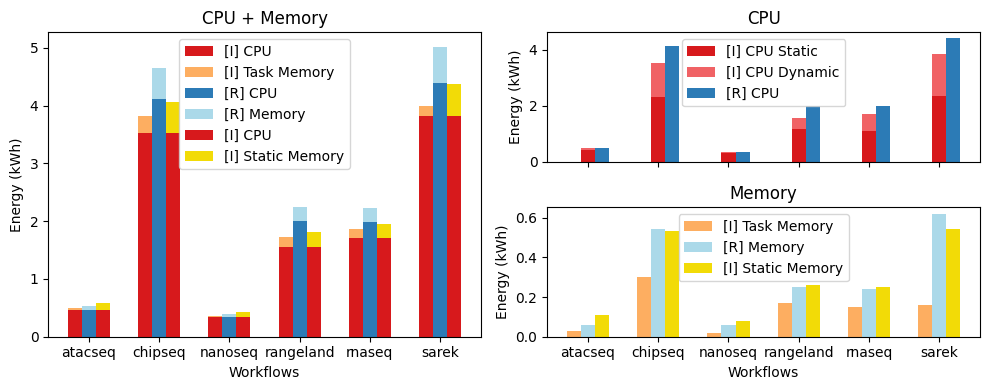

In [18]:
# Ichnos (energy visualisation)
layout = [['L', 'T'], ['L', 'B']]
fig, axs = plt.subplot_mosaic(layout, figsize=(10, 4), sharex=True)

wfs = median_rows_hu.index
x = np.arange(6)
width = 0.2

# cpu + memory
axs['L'].set_title('CPU + Memory')
axs['L'].bar(x - width, median_rows_hu['ichnos_pkg'].values, width, label='[I] CPU', color='#d7191c')
axs['L'].bar(x - width, median_rows_hu['ichnos_task_mem'].values, width, bottom=median_rows_hu['ichnos_pkg'].values, label='[I] Task Memory', color='#fdae61')
axs['L'].bar(x, median_rows_hu['rapl_pkg'].values, width, label='[R] CPU', color='#2c7bb6')
axs['L'].bar(x, median_rows_hu['rapl_mem'].values, width, bottom=median_rows_hu['rapl_pkg'].values, label='[R] Memory', color='#abd9e9')
axs['L'].bar(x + width, median_rows_hu['ichnos_pkg'].values, width, label='[I] CPU', color='#d7191c')
axs['L'].bar(x + width, median_rows_hu['ichnos_static_mem'].values, width, bottom=median_rows_hu['ichnos_pkg'].values, label='[I] Static Memory', color='#f2db07')
axs['L'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['L'].set_ylabel('Energy (kWh)')
axs['L'].legend(loc='upper center')

# cpu
axs['T'].set_title('CPU')
axs['T'].bar(x, median_rows_hu['ichnos_static_cpu'].values, width, label='[I] CPU Static', color='#d7191c')
axs['T'].bar(x, median_rows_hu['ichnos_pkg'].values - median_rows_hu['ichnos_static_cpu'].values, width, bottom=median_rows_hu['ichnos_static_cpu'].values, label='[I] CPU Dynamic', color='#f06265')
axs['T'].bar(x + width, median_rows_hu['rapl_pkg'].values, width, label='[R] CPU', color='#2c7bb6')
axs['T'].set_ylabel('Energy (kWh)')
axs['T'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['T'].legend(loc='upper center')

# memory
axs['B'].set_title('Memory')
axs['B'].bar(x - width, median_rows_hu['ichnos_task_mem'].values, width, label='[I] Task Memory', color='#fdae61')
axs['B'].bar(x, median_rows_hu['rapl_mem'].values, width, label='[R] Memory', color='#abd9e9')
axs['B'].bar(x + width, median_rows_hu['ichnos_static_mem'].values, width, label='[I] Static Memory', color='#f2db07')
axs['B'].set_ylabel('Energy (kWh)')
axs['B'].set_xticks(x, labels=median_rows_hu['workflow'].values)
axs['B'].legend(loc='upper center')

axs['B'].set_xlabel('Workflows')
axs['L'].set_xlabel('Workflows')

plt.tight_layout()

def save_subplot(fig, ax, path, padding=1.1):
    renderer = fig.canvas.get_renderer()
    bbox_display = ax.get_tightbbox(renderer)
    bbox_inches = bbox_display.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(path, bbox_inches=bbox_inches.expanded(padding, padding))

save_subplot(fig, axs['L'], "images/ichnos-vs-rapl-total.pdf")
save_subplot(fig, axs['T'], "images/ichnos-vs-rapl-cpu.pdf")
save_subplot(fig, axs['B'], "images/ichnos-vs-rapl-memory.pdf")
plt.savefig('images/ichnos-vs-rapl.pdf')
plt.show()

In [19]:
def load_nfco2fp_summary(cluster, workflow, run):
    filepath = f'nf-co2footprint/output/{cluster}-cluster/co2fp-summary-{workflow}-{run}.txt'
    with open(filepath, 'r') as file:
        data = file.readlines()

    energy_val, energy_unit = data[2].split(':')[1].strip().split(' ')
    if energy_unit == 'Wh':
        return float(energy_val) / 1000
    elif energy_unit == 'kWh':
        return float(energy_val)

In [20]:
print('hu-cluster')
hu_copy = rows_hu.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only', 'ichnos_statmem']
hu_data = []
hu_idle_cpu = 51.2  # W
hu_idle_mem = 7.3  # W

for _, row in hu_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    i_total_statmem = round(row['ichnos_pkg'] + row['ichnos_static_mem'], 2)
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('hu', wf, run)

    # calculate static_energy for the nf-co2footprint plugin
    nxf_trace, _ = load_nxf_trace('hu', wf, run, print=False)
    tasks_by_node = nxf_trace.groupby('hostname')
    idle_energy = 0.0
    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/hu-cluster/{wf}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        node_active_time = np.sum(periods_df['duration_ms']) / 1000 / 60 / 60
        node_energy = node_active_time * (hu_idle_cpu + hu_idle_mem) * 0.001  # convert to kWh
        idle_energy += node_energy

    nfco2_total = round(nfco2_dynamic + idle_energy, 2)
    hu_data.append([wf, run, i_total, r_total, nfco2_total, round(nfco2_dynamic, 2), round(idle_energy, 2), i_total_statmem])

print(tabulate(hu_data, headers=heads))

hu-cluster
wf           run    ichnos    rapl    nfco2    dyn_only    stat_only    ichnos_statmem
---------  -----  --------  ------  -------  ----------  -----------  ----------------
rnaseq         1      1.85    2.22     2.05        1.12         0.93              1.95
rnaseq         2      1.86    2.23     2.05        1.11         0.94              1.96
rnaseq         3      1.87    2.25     2.06        1.11         0.95              1.98
chipseq        1      3.83    4.66     4.23        2.28         1.95              4.06
chipseq        2      3.82    4.66     4.22        2.28         1.94              4.04
chipseq        3      3.81    4.65     4.21        2.27         1.94              4.04
atacseq        1      0.49    0.51     0.4         0.15         0.25              0.57
atacseq        2      0.5     0.53     0.4         0.14         0.26              0.58
atacseq        3      0.51    0.54     0.41        0.14         0.27              0.59
rangeland      1      1.73    2.

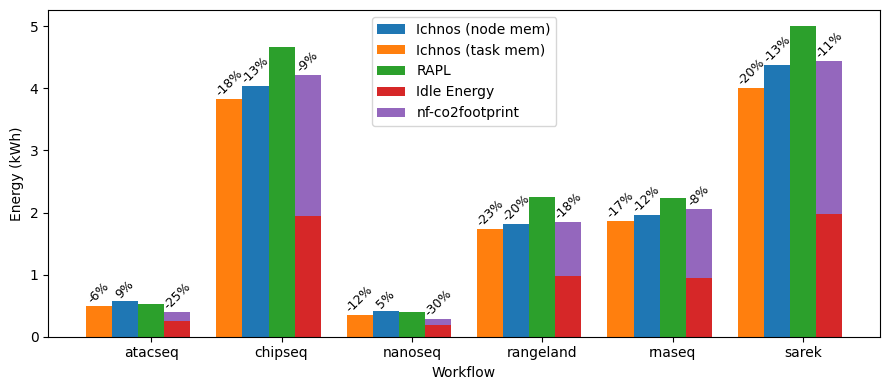

In [21]:
hu_baseline_comp = pd.DataFrame(hu_data, columns=heads)
hu_baseline_grouped = hu_baseline_comp.groupby('wf').median()

wfs = hu_baseline_grouped.index
x = np.arange(6)
width = 0.2
fig, ax = plt.subplots(figsize=(9, 4))

bars = {
    'ichnos_statmem': ax.bar(x - (width * 1), hu_baseline_grouped['ichnos_statmem'].values, width, label='Ichnos (node mem)'),
    'ichnos':         ax.bar(x - (width * 2),        hu_baseline_grouped['ichnos'].values,         width, label='Ichnos (task mem)'),
    'rapl':           ax.bar(x,                 hu_baseline_grouped['rapl'].values,            width, label='RAPL'),
}

stat_vals = hu_baseline_grouped['stat_only'].values
dyn_vals  = hu_baseline_grouped['dyn_only'].values
bars['stat_only'] = ax.bar(x + width, stat_vals,  width, label='Idle Energy')
bars['dyn_only']  = ax.bar(x + width, dyn_vals,   width, bottom=stat_vals, label='nf-co2footprint')

rapl = hu_baseline_grouped['rapl'].values

def annotate_bars(bar_container, values, offsets=None):
    for i, (bar, val) in enumerate(zip(bar_container, values)):
        error = get_error_dir(val, rapl[i])
        bar_top = bar.get_height() + (offsets[i] if offsets is not None else 0)
        ax.text(bar.get_x() + bar.get_width() / 2, bar_top, f'{error:.0f}%', ha='center', va='bottom', rotation=45, fontsize=9)

annotate_bars(bars['ichnos_statmem'], hu_baseline_grouped['ichnos_statmem'].values)
annotate_bars(bars['ichnos'],         hu_baseline_grouped['ichnos'].values)
annotate_bars(bars['dyn_only'], stat_vals + dyn_vals, offsets=stat_vals)

ax.set_ylabel('Energy (kWh)')
ax.set_xticks(x, wfs)
ax.set_xlabel('Workflow')
ax.legend()

plt.tight_layout()
plt.savefig('images/ichnos-vs-nfco2-hu.pdf')
# plt.show()

In [22]:
print('gu-cluster')
gu_copy = rows_gu.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only', 'ichnos_statmem']
gu_data = []
gu_idle_cpu = 1547.72 / 30.001519643
gu_idle_mem = 432.73 / 30.001519643

for _, row in gu_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    i_total_statmem = round(row['ichnos_pkg'] + row['ichnos_static_mem'], 2)
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('gu', wf, run)

    # calculate static_energy for the nf-co2footprint plugin
    nxf_trace, _ = load_nxf_trace('gu', wf, run, print=False)
    tasks_by_node = nxf_trace.groupby('hostname')
    idle_energy = 0.0
    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/gu-cluster/{wf}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        node_active_time = np.sum(periods_df['duration_ms']) / 1000 / 60 / 60
        node_energy = node_active_time * (gu_idle_cpu + gu_idle_mem) * 0.001  # convert to kWh
        idle_energy += node_energy

    nfco2_total = round(nfco2_dynamic + idle_energy, 2)
    gu_data.append([wf, run, i_total, r_total, nfco2_total, round(nfco2_dynamic, 2), round(idle_energy, 2), i_total_statmem])

print(tabulate(gu_data, headers=heads))

gu-cluster
wf         run    ichnos    rapl    nfco2    dyn_only    stat_only    ichnos_statmem
-------  -----  --------  ------  -------  ----------  -----------  ----------------
atacseq      1      1.04    1.07     1.3         0.45         0.86              1.1
atacseq      2      1.03    1.09     1.3         0.45         0.86              1.09
atacseq      3      1.04    1.08     1.3         0.44         0.86              1.1
chipseq      1      1.45    1.53     1.92        0.68         1.24              1.54
chipseq      2      1.44    1.54     1.91        0.68         1.24              1.53
chipseq      3      1.47    1.54     1.94        0.68         1.26              1.55
nanoseq      1      0.65    0.7      0.84        0.28         0.56              0.69
nanoseq      2      0.62    0.68     0.82        0.28         0.54              0.66
nanoseq      3      0.64    0.7      0.83        0.28         0.55              0.68
rnaseq       1      1.09    1.16     1.39        0.43   

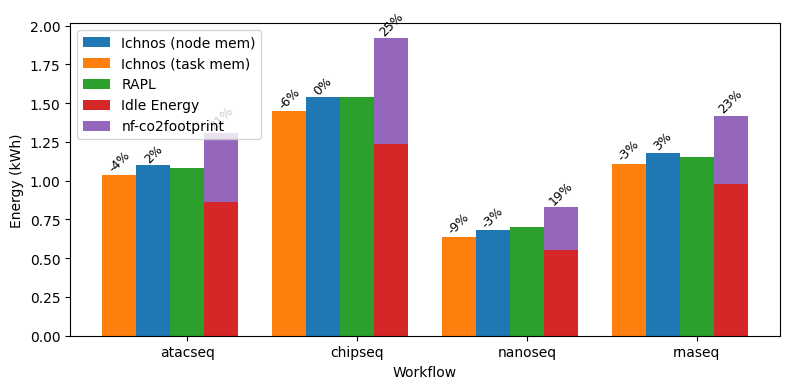

In [23]:
gu_baseline_comp = pd.DataFrame(gu_data, columns=heads)
gu_baseline_grouped = gu_baseline_comp.groupby('wf').median()

wfs = gu_baseline_grouped.index
x = np.arange(4)
width = 0.20
fig, ax = plt.subplots(figsize=(8, 4))

bars = {
    'ichnos_statmem': ax.bar(x - (width * 1), gu_baseline_grouped['ichnos_statmem'].values, width, label='Ichnos (node mem)'),
    'ichnos':         ax.bar(x - (width * 2),        gu_baseline_grouped['ichnos'].values,         width, label='Ichnos (task mem)'),
    'rapl':           ax.bar(x,                 gu_baseline_grouped['rapl'].values,            width, label='RAPL'),
}

stat_vals = gu_baseline_grouped['stat_only'].values
dyn_vals  = gu_baseline_grouped['dyn_only'].values
bars['stat_only'] = ax.bar(x + width, stat_vals,  width, label='Idle Energy')
bars['dyn_only']  = ax.bar(x + width, dyn_vals,   width, bottom=stat_vals, label='nf-co2footprint')

rapl = gu_baseline_grouped['rapl'].values

def annotate_bars(bar_container, values, offsets=None):
    for i, (bar, val) in enumerate(zip(bar_container, values)):
        error = get_error_dir(val, rapl[i])
        bar_top = bar.get_height() + (offsets[i] if offsets is not None else 0)
        ax.text(bar.get_x() + bar.get_width() / 2, bar_top, f'{error:.0f}%', ha='center', va='bottom', rotation=45, fontsize=9)

annotate_bars(bars['ichnos_statmem'], gu_baseline_grouped['ichnos_statmem'].values)
annotate_bars(bars['ichnos'],         gu_baseline_grouped['ichnos'].values)
annotate_bars(bars['dyn_only'], stat_vals + dyn_vals, offsets=stat_vals)

ax.set_ylabel('Energy (kWh)')
ax.set_xticks(x, wfs)
ax.set_xlabel('Workflow')
ax.legend()

plt.tight_layout()
plt.savefig('images/ichnos-vs-nfco2-gu.pdf')
# plt.show()

In [24]:
print('aws-cluster')
aws_copy = rows_aws.copy()
heads = ['wf', 'run', 'ichnos', 'rapl', 'nfco2', 'dyn_only', 'stat_only', 'ichnos_statmem']
aws_data = []
aws_idle_cpu = (60.41 + 108.75) / 2
aws_idle_mem = (45.09 + 57.73) / 2

for _, row in aws_copy.iterrows():
    wf = row['workflow']
    run = row['run']
    i_total = row['ichnos_total']
    i_total_statmem = round(row['ichnos_pkg'] + row['ichnos_static_mem'], 2)
    r_total = row['rapl_total']
    nfco2_dynamic = load_nfco2fp_summary('aws', wf, run)

    # calculate static_energy for the nf-co2footprint plugin
    nxf_trace, _ = load_nxf_trace('aws', wf, run, print=False)
    tasks_by_node = nxf_trace.groupby('hostname')
    idle_energy = 0.0
    for node, group_df in tasks_by_node:
        node_id = node.split('-')[-1].strip()
        node_active_periods_file = f'nxf-experiments/aws-cluster/{wf}/{run}/energy/active_{node_id}.csv'
        periods_df = pd.read_csv(node_active_periods_file)
        node_active_time = np.sum(periods_df['duration_ms']) / 1000 / 60 / 60
        node_energy = node_active_time * (aws_idle_cpu + aws_idle_mem) * 0.001  # convert to kWh
        idle_energy += node_energy

    nfco2_total = round(nfco2_dynamic + idle_energy, 2)
    aws_data.append([wf, run, i_total, r_total, nfco2_total, round(nfco2_dynamic, 2), round(idle_energy, 2), i_total_statmem])

print(tabulate(aws_data, headers=heads))

aws_baseline_comp = pd.DataFrame(aws_data, columns=heads)
aws_baseline_grouped = aws_baseline_comp.groupby('wf').median()

aws-cluster
wf         run    ichnos    rapl    nfco2    dyn_only    stat_only    ichnos_statmem
-------  -----  --------  ------  -------  ----------  -----------  ----------------
atacseq      1      0.76    0.97     0.66        0.18         0.48              0.89
atacseq      2      0.76    0.97     0.65        0.18         0.47              0.89
atacseq      3      0.77    0.99     0.66        0.18         0.48              0.91
chipseq      1      3.51    4.59     3.01        0.94         2.07              4.01
chipseq      2      3.56    4.7      3.05        0.94         2.11              4.08
chipseq      3      3.55    4.71     3.04        0.95         2.09              4.06
nanoseq      1      0.42    0.56     0.34        0.11         0.23              0.49
nanoseq      2      0.4     0.55     0.33        0.1          0.23              0.47
nanoseq      3      0.41    0.55     0.33        0.1          0.23              0.48
rnaseq       1      4.15    5.5      3.68        0.96

In [25]:
# prepare table with red/green and best values highlighted in bold
def print_baseline_table(data):
    ichnos_errors = []
    nfco2_errors = []

    for (_, row), wf in zip(data.iterrows(), data.index):
        rapl = row['rapl']
        ichnos_node = row['ichnos_statmem']
        ichnos_task = row['ichnos']
        nfco2 = row['nfco2']
        ichnos_node_err = get_error_dir(ichnos_node, rapl)
        ichnos_task_err = get_error_dir(ichnos_task, rapl)
        nfco2_err = get_error_dir(nfco2, rapl)
        ichnos_errors.append(abs(ichnos_node_err))
        nfco2_errors.append(abs(nfco2_err))

        if abs(ichnos_node_err) < abs(nfco2_err):
            pre_ichnos = '\\cellcolor{Green!30}\\textbf{{'
            pre_nfco2 = ''
            post_ichnos = '}}'
            post_nfco2 = ''
        else:
            pre_ichnos = ''
            pre_nfco2 = '\\cellcolor{Green!30}\\textbf{{'
            post_ichnos = ''
            post_nfco2 = '}}'

        if ichnos_node_err > 0:
            ichnos_node_err = f'{pre_ichnos}+{ichnos_node_err:.2f}{post_ichnos}'
        else:
            ichnos_node_err = f'{pre_ichnos}{ichnos_node_err:.2f}{post_ichnos}'

        if nfco2_err > 0:
            nfco2_err = f'{pre_nfco2}+{nfco2_err:.2f}{post_nfco2}'
        else:
            nfco2_err = f'{pre_nfco2}{nfco2_err:.2f}{post_nfco2}'

        print(f'{wf} & {rapl:.2f} & {ichnos_node:.2f} & {ichnos_node_err} & {nfco2:.2f} & {nfco2_err} \\\\')

    print(f'Average & \\cellcolor{{Gray!30}} & \\cellcolor{{Gray!30}} & {np.mean(ichnos_errors):.2f} & \\cellcolor{{Gray!30}} & {np.mean(nfco2_errors):.2f} \\\\')

print('Ichnos vs. Baseline (nf-co2footprint)')
print('gu-cluster')
print_baseline_table(gu_baseline_grouped)
print('hu-cluster')
print_baseline_table(hu_baseline_grouped)
print('aws-cluster')
print_baseline_table(aws_baseline_grouped)


Ichnos vs. Baseline (nf-co2footprint)
gu-cluster
atacseq & 1.08 & 1.10 & \cellcolor{Green!30}\textbf{{+1.85}} & 1.30 & +20.37 \\
chipseq & 1.54 & 1.54 & \cellcolor{Green!30}\textbf{{0.00}} & 1.92 & +24.68 \\
nanoseq & 0.70 & 0.68 & \cellcolor{Green!30}\textbf{{-2.86}} & 0.83 & +18.57 \\
rnaseq & 1.15 & 1.18 & \cellcolor{Green!30}\textbf{{+2.61}} & 1.42 & +23.48 \\
Average & \cellcolor{Gray!30} & \cellcolor{Gray!30} & 1.83 & \cellcolor{Gray!30} & 21.77 \\
hu-cluster
atacseq & 0.53 & 0.58 & \cellcolor{Green!30}\textbf{{+9.43}} & 0.40 & -24.53 \\
chipseq & 4.66 & 4.04 & -13.30 & 4.22 & \cellcolor{Green!30}\textbf{{-9.44}} \\
nanoseq & 0.40 & 0.42 & \cellcolor{Green!30}\textbf{{+5.00}} & 0.28 & -30.00 \\
rangeland & 2.25 & 1.81 & -19.56 & 1.83 & \cellcolor{Green!30}\textbf{{-18.67}} \\
rnaseq & 2.23 & 1.96 & -12.11 & 2.05 & \cellcolor{Green!30}\textbf{{-8.07}} \\
sarek & 5.01 & 4.38 & -12.57 & 4.43 & \cellcolor{Green!30}\textbf{{-11.58}} \\
Average & \cellcolor{Gray!30} & \cellcolor{Gray!3

**Comparison of Linear and Polynomial Models**

In [26]:
class Polynomial:
    def __init__(self, coefficients):
        self.coeffs = coefficients

    def __str__(self):
        chunks = []
        for coeff, power in zip(self.coeffs, range(len(self.coeffs), -1, -1)):
            if coeff == 0:
                continue
            chunks.append('(')
            chunks.append(self.format_coeff(coeff))
            chunks.append(self.format_power(power))
            chunks.append(') +')
        return ' '.join(chunks)

    @staticmethod
    def format_coeff(coeff):
        return str(coeff) if coeff < 0 else "{0}".format(coeff)

    @staticmethod
    def format_power(power):
        return ' * (x ** {0})'.format(power) if power != 0 else ''

def read_ts(filename):
    ts_data = {}

    with open(filename, 'r') as f:
        data = f.readlines()

    for load, row_i in zip(range(0, 100, 10), range(1,12)):
        ts_data[load] = float(data[row_i].strip().split(',')[3])

    ts_data[100] = float(data[14].strip().split(',')[3])  # power consumption with maximize stress test

    mem_idle = float(data[1].strip().split(',')[4])
    mem_max = float(data[13].strip().split(',')[4])  # memory power consumption with VMStress stress test

    return (ts_data, (mem_idle, mem_max))

def get_average_ts_files(path):
    paths = [path.replace('ITER', str(iteration)) for iteration in range(1, 4)]
    readings = {}
    mem_readings = []

    for path in paths:
        (path_data, mem_data) = read_ts(path)

        for load,val in path_data.items():
            if load in readings:
                readings[load].append(val)
            else:
                readings[load] = [val]

        avg_mem_draw = (mem_data[0] + mem_data[1]) / 2
        mem_readings.append(avg_mem_draw)

    data = {}

    for load,vals in readings.items():
        data[load] = sum(vals) / 3

    overall_avg_mem_draw = sum(mem_readings) / 3

    return (data, overall_avg_mem_draw)

def get_linear_predictions(min, max):
    return [(min + (usage / 100) * (max - min)) for usage in range(0, 110, 10)]

def get_mem_vals(node, gov, background=False):
    shortnode = node.replace('-', '')
    if background:
        mem_file = f'../data/memory-bg/memory-{shortnode}-{gov}.csv'
    else:
        mem_file = f'../data/memory/memory-{shortnode}-{gov}.csv'
    recs = pd.read_csv(mem_file, header=0)
    return recs['watts'].values

In [27]:
def plot_cpu_mem_energy_consumption(nodes, govs, cluster, paper_name):
    overall_max_cpu = -1
    overall_max_mem = -1
    f, axs = plt.subplots(ncols=len(govs), nrows=2, sharex=True, figsize=(12,3), gridspec_kw = {'height_ratios':[12, 2]})
    f.tight_layout(pad=0)
    rmse_by_model = {'naive-linear': [], 'fitted-linear': [], 'fitted-cubic': []}
    colours = ['#d73027', '#4575b4', 'green', 'orange']

    for node, colour_ind in zip(nodes, range(0, len(nodes))):
        ts_paths = [f'../data/{node}/ts-{node.replace('-', '')}-{governor}-ITER.csv' for governor in govs]
        node_stats = {}

        for ts_path, gov, col in zip(ts_paths, govs, range(0, len(govs))):
            (node_stats[f"{node}:{gov}"], _) = get_average_ts_files(ts_path)
            x = range(0, 110, 10)
            y = node_stats[f"{node}:{gov}"].values()
            y_arr = list(y)

            # Ichnos-Cubic
            p = np.poly1d(np.polyfit(x, y_arr, 3))
            xp = np.linspace(0, 100)
            axs[0][col].plot(xp, p(xp), label=f'Fitted Cubic', color=colours[colour_ind], linestyle='solid')
            y_pred = [p(x_val) for x_val in x]
            cubic_rmse = root_mean_squared_error(y_arr, y_pred)
            rmse_by_model['fitted-cubic'].append(cubic_rmse)

            # Naive-Linear
            linear_pred = get_linear_predictions(y_arr[0], y_arr[-1])
            axs[0][col].plot(x, linear_pred, label=f'Naive Linear', color=colours[colour_ind], linestyle='dashed')
            linear_rmse = root_mean_squared_error(y_arr, linear_pred)
            rmse_by_model['naive-linear'].append(linear_rmse)

            # Ichnos-Linear
            linear_v2_coef = np.polyfit(x, y_arr, 1)
            linear_v2 = np.poly1d(linear_v2_coef)
            linear_v2_x = np.linspace(0, 100)
            axs[0][col].plot(linear_v2_x, linear_v2(linear_v2_x), label=f'Fitted Linear', color=colours[colour_ind], linestyle='dotted')
            linear_v2_pred = [linear_v2(x_val) for x_val in x]
            fitted_linear_rmse = root_mean_squared_error(y_arr, linear_v2_pred)
            rmse_by_model['fitted-linear'].append(fitted_linear_rmse)

            # RAPL (perf) Readings
            axs[0][col].scatter(x, y, marker='x', label=f'Turbostress', color=colours[colour_ind])

            if max(y) > overall_max_cpu:
                overall_max_cpu = max(y)

            axs[0][col].set_ylim(40, max(y) + 10)

        for gov, col in zip(govs, range(0, len(govs))):
            x = range(0, 110, 10)
            y = get_mem_vals(node, gov)
            axs[1][col].plot(x, y, label={gov}, color=colours[colour_ind])

            if max(y) > overall_max_mem:
                overall_max_mem = max(y)


    f.text(0.15, 1.01, 'performance', ha='center')
    f.text(0.40, 1.01, 'powersave', ha='center')
    f.text(0.65, 1.01, 'ondemand', ha='center')
    f.text(0.88, 1.01, 'schedutil', ha='center')
    f.text(0.52, -0.04, 'Load (%)', ha='center')

    for col in range(0, len(govs)):
        axs[0][col].set_ylim(40, overall_max_cpu + 15)
        axs[1][col].set_ylim(5, 20)
    axs[0][0].set_xticks(range(0,110,10))

    legend_elements = [
        Patch(facecolor='white', label='Nodes'),
    ]

    for node, col_ind in zip(nodes, range(0, len(nodes))):
        node_id = node.split('-')[-1]
        if 'c' in node_id:
            node_id = node_id[1:]
        legend_elements.append(Patch(facecolor=colours[col_ind], label=f'{paper_name}-{node_id}'))

    legend_elements.extend([
        Patch(facecolor='white', label='\nModel'),
        Line2D([0], [0], color='black', lw=2, label='Fitted Cubic'),
        Line2D([0], [0], color='black', lw=2, linestyle='dotted', label='Fitted Linear'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Naive Linear'),
        Line2D([0], [0], marker='x', color='black', label='Turbostress', markerfacecolor='black', markersize=15)
    ]) 

    f.legend(handles=legend_elements, bbox_to_anchor=(1.12, 0.92), frameon=False, prop={'size': 10})
    f.text(-0.02, 0.5, 'Energy Consumption (W)', ha='center', va='center', rotation='vertical')
    print(f'naive linear: {np.mean(rmse_by_model['naive-linear']):.1f}')
    print(f'fitted linear: {np.mean(rmse_by_model['fitted-linear']):.1f}')
    print(f'fitted cubic: {np.mean(rmse_by_model['fitted-cubic']):.1f}')

    plt.rcParams.update({'font.size': 12})
    plt.savefig(f'images/governor-variation-{cluster}.pdf', bbox_inches='tight')
    plt.show()

In [28]:
def plot_diff_nodes_same_gov(nodes, govs, cluster, paper_name):
    overall_max_cpu = -1
    overall_max_mem = -1
    f, axs = plt.subplots(ncols=1, nrows=2, sharex=True, figsize=(4,3), gridspec_kw = {'height_ratios':[6, 3]})
    f.tight_layout(pad=0)
    rmse_by_model = {'naive-linear': [], 'fitted-linear': [], 'fitted-cubic': []}
    colours = ['#d73027', '#4575b4']

    for node, colour_ind in zip(nodes, range(0, len(nodes))):
        ts_paths = [f'../data/{node}/ts-{node.replace('-', '')}-{governor}-ITER.csv' for governor in govs]
        node_stats = {}

        for ts_path, gov in zip(ts_paths, govs):
            (node_stats[f"{node}:{gov}"], _) = get_average_ts_files(ts_path)
            x = range(0, 110, 10)
            y = node_stats[f"{node}:{gov}"].values()
            y_arr = list(y)

            # Ichnos-Cubic
            p = np.poly1d(np.polyfit(x, y_arr, 3))
            xp = np.linspace(0, 100)
            axs[0].plot(xp, p(xp), label=f'Fitted Cubic', color=colours[colour_ind], linestyle='solid')
            y_pred = [p(x_val) for x_val in x]
            cubic_rmse = root_mean_squared_error(y_arr, y_pred)
            rmse_by_model['fitted-cubic'].append(cubic_rmse)

            # Naive-Linear
            linear_pred = get_linear_predictions(y_arr[0], y_arr[-1])
            axs[0].plot(x, linear_pred, label=f'Naive Linear', color=colours[colour_ind], linestyle='dashed')
            linear_rmse = root_mean_squared_error(y_arr, linear_pred)
            rmse_by_model['naive-linear'].append(linear_rmse)

            # Ichnos-Linear
            linear_v2_coef = np.polyfit(x, y_arr, 1)
            linear_v2 = np.poly1d(linear_v2_coef)
            linear_v2_x = np.linspace(0, 100)
            axs[0].plot(linear_v2_x, linear_v2(linear_v2_x), label=f'Fitted Linear', color=colours[colour_ind], linestyle='dotted')
            linear_v2_pred = [linear_v2(x_val) for x_val in x]
            fitted_linear_rmse = root_mean_squared_error(y_arr, linear_v2_pred)
            rmse_by_model['fitted-linear'].append(fitted_linear_rmse)

            # RAPL (perf) Readings
            axs[0].scatter(x, y, marker='x', label=f'Turbostress', color=colours[colour_ind])

            if max(y) > overall_max_cpu:
                overall_max_cpu = max(y)

        for gov in govs:
            x = range(0, 110, 10)
            y = get_mem_vals(node, gov)
            axs[1].plot(x, y, label={gov}, color=colours[colour_ind])

            if max(y) > overall_max_mem:
                overall_max_mem = max(y)

    f.text(0.52, -0.04, 'Load (%)', ha='center')

    axs[0].set_ylim(40, overall_max_cpu + 15)
    axs[1].set_ylim(5, 20)
    axs[0].set_xticks(range(0,110,10))

    legend_elements = [
        Patch(facecolor='white', label='Nodes'),
        Patch(facecolor='#d73027', label=f'{paper_name}-{nodes[0].split('-')[-1]}'),
        Patch(facecolor='#4575b4', label=f'{paper_name}-{nodes[1].split('-')[-1]}'),
        Patch(facecolor='white', label='\nModel'),
        Line2D([0], [0], color='black', lw=2, label='Fitted Cubic'),
        Line2D([0], [0], color='black', lw=2, linestyle='dotted', label='Fitted Linear'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Naive Linear'),
        Line2D([0], [0], marker='x', color='black', label='Turbostress', markerfacecolor='black', markersize=15),
    ]

    f.legend(handles=legend_elements, bbox_to_anchor=(1.35, 0.92), frameon=False, prop={'size': 10})
    f.text(-0.02, 0.5, 'Energy Consumption (W)', ha='center', va='center', rotation='vertical')
    print(f'naive linear: {np.mean(rmse_by_model['naive-linear']):.1f}')
    print(f'fitted linear: {np.mean(rmse_by_model['fitted-linear']):.1f}')
    print(f'fitted cubic: {np.mean(rmse_by_model['fitted-cubic']):.1f}')

    plt.rcParams.update({'font.size': 12})
    plt.savefig(f'images/node-variations-{cluster}.pdf', bbox_inches='tight')
    plt.show()


In [29]:
def load_power_model(node, gov, background):
    if background:
        filename = f'../data/models/{gov}-{node}-model.txt'
    else:
        filename = f'../data/models/{gov}-{node}-noload-model.txt'

    with open(filename, 'r') as f:
        model = f.readlines()[1].strip()[2:-2]

    return model

def plot_cpu_mem_background_comp(nodes, govs):
    model_by_setting = {}

    for node in nodes:
        model_by_setting[node] = {}
        for gov in govs:
            model_by_setting[node][gov] = {}
            model_by_setting[node][gov]['cluster-up'] = load_power_model(node, gov, True)
            model_by_setting[node][gov]['cluster-down'] = load_power_model(node, gov, False)

    model_coeff_change = []
    model_inter_change = []

    for node in nodes:
        for gov in govs:
            up_coeff, up_inter = model_by_setting[node][gov]['cluster-up'].split(', ')
            down_coeff, down_inter = model_by_setting[node][gov]['cluster-down'].split(', ')
            model_coeff_change.append((float(up_coeff) - float(down_coeff)))
            model_inter_change.append((float(up_inter) - float(down_inter)))

    print(f'median change in model coefficient: {np.median(model_coeff_change):.2f}W')
    print(f'median change in static power draw: {np.median(model_inter_change):.2f}W')

naive linear: 11.2
fitted linear: 5.4
fitted cubic: 0.6


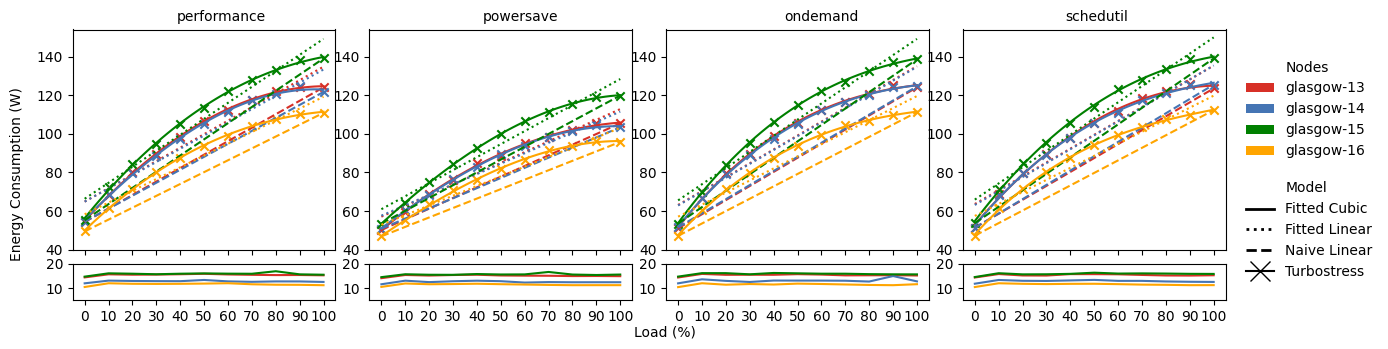

In [30]:
# gpg cluster nodes
nodes = ['gpgnode-13', 'gpgnode-14', 'gpgnode-15', 'gpgnode-16']
govs = ['performance', 'powersave', 'ondemand', 'schedutil']

plot_cpu_mem_energy_consumption(nodes, govs, 'gu', 'glasgow')

naive linear: 11.8
fitted linear: 5.9
fitted cubic: 0.5


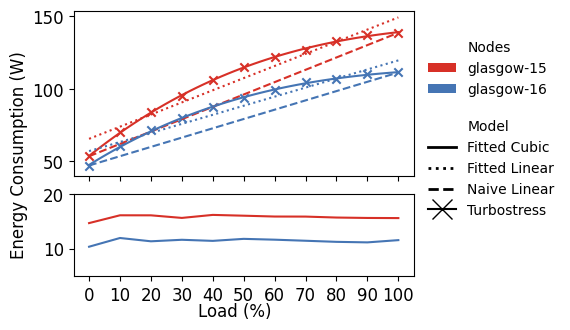

In [31]:
# gpg cluster nodes
nodes = ['gpgnode-15', 'gpgnode-16']
govs = ['ondemand']

plot_diff_nodes_same_gov(nodes, govs, 'gu', 'glasgow')

naive linear: 16.5
fitted linear: 8.9
fitted cubic: 2.5


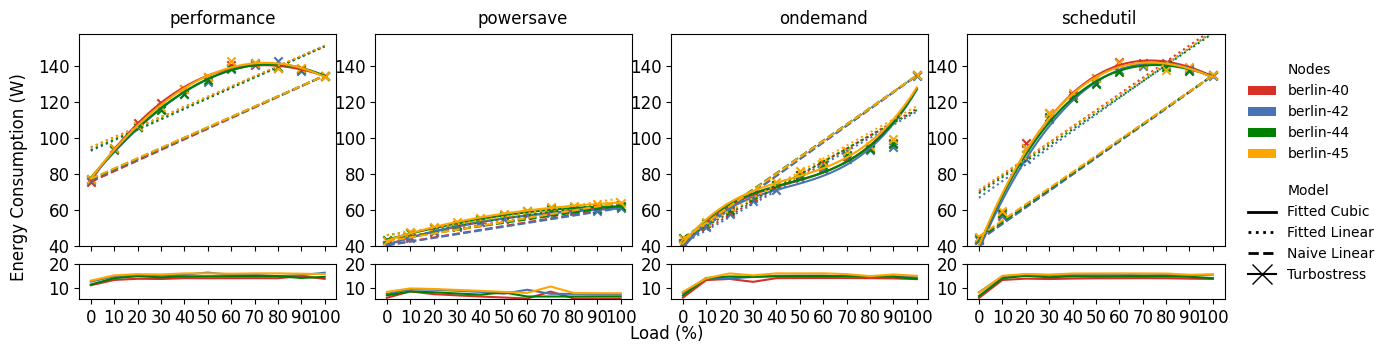

In [32]:
# hu cluster nodes
nodes = ['hu-worker-c40', 'hu-worker-c42', 'hu-worker-c44', 'hu-worker-c45']
govs = ['performance', 'powersave', 'ondemand', 'schedutil']

plot_cpu_mem_energy_consumption(nodes, govs, 'hu', 'berlin')

In [33]:
experiments = ['high_cpu_high_mem', 'high_cpu_low_mem', 'high_cpu_med_mem', 'low_cpu_high_mem', 'low_cpu_low_mem', 'med_cpu_high_mem', 'med_cpu_med_mem']
airflow = {'high_cpu_high_mem': {}, 'high_cpu_low_mem': {}, 'high_cpu_med_mem': {}, 'low_cpu_high_mem': {}, 'low_cpu_low_mem': {}, 'med_cpu_high_mem': {}, 'med_cpu_med_mem': {}}

for experiment in experiments:
    airflow[experiment]['rapl'] = process_airflow_rapl_data(load_airflow_rapl_readings(experiment))
    airflow[experiment]['ichnos'] = {}

    for run in range(1, 4):
        airflow[experiment]['ichnos'][run] = {}
        (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'aflow-experiments/{experiment}/ichnos/{experiment}-{run}-1-schedutil_linear-summary.txt')
        airflow[experiment]['ichnos'][run]['pkg'] = cpu
        airflow[experiment]['ichnos'][run]['mem_dyn'] = task_mem
        airflow[experiment]['ichnos'][run]['mem_stat'] = node_mem 
        airflow[experiment]['ichnos'][run]['total'] = cpu + task_mem
        airflow[experiment]['ichnos'][run]['pkg_stat'] = cpu_stat

headers = ['experiment', 'run', 'i_pkg', 'r_pkg', 'pkg_error', 'i_dram', 'r_dram', 'dram_error', 'i_total', 'r_total', 'total_error']
data = []

for experiment in experiments:
    for run in range(1, 4):
        rapl_pkg = round(airflow[experiment]['rapl'][run]['pkg'], 3)
        rapl_dram = round(airflow[experiment]['rapl'][run]['dram'], 3)
        rapl_total = round(airflow[experiment]['rapl'][run]['total'], 3)
        ichnos_pkg = round(airflow[experiment]['ichnos'][run]['pkg'], 3)
        ichnos_dram = round(airflow[experiment]['ichnos'][run]['mem_stat'], 3)
        ichnos_total = ichnos_pkg + ichnos_dram
        data.append([experiment, run, ichnos_pkg, rapl_pkg, get_error_dir(ichnos_pkg, rapl_pkg), ichnos_dram, rapl_dram, get_error_dir(ichnos_dram, rapl_dram), ichnos_total, rapl_total, get_error_dir(ichnos_total, rapl_total)])

airflow_df = pd.DataFrame(data, columns=headers)
airflow_median = airflow_df.sort_values(['experiment', 'r_total']).groupby('experiment').nth(1)
print('schedutil_linear')
print(airflow_median)
print('')

for _, row in airflow_median.iterrows():
    print(f'& {row['i_pkg']:.3f} & {row['r_pkg']:.3f} & {row['pkg_error']:.1f} & {row['i_dram']:.3f} & {row['r_dram']:.3f} & {row['dram_error']:.1f} & {row['i_total']:.3f} & {row['r_total']:.3f} & {row['total_error']:.1f} \\\\')

schedutil_linear
           experiment  run  i_pkg  r_pkg  pkg_error  i_dram  r_dram  dram_error  i_total  r_total  total_error
1   high_cpu_high_mem    2  0.210  0.255     -17.65   0.042   0.045       -6.67    0.252    0.300       -16.00
5    high_cpu_low_mem    3  0.215  0.260     -17.31   0.043   0.051      -15.69    0.258    0.310       -16.77
7    high_cpu_med_mem    2  0.216  0.255     -15.29   0.043   0.046       -6.52    0.259    0.301       -13.95
10   low_cpu_high_mem    2  0.194  0.124      56.45   0.044   0.026       69.23    0.238    0.150        58.67
13    low_cpu_low_mem    2  0.190  0.121      57.02   0.043   0.028       53.57    0.233    0.149        56.38
16   med_cpu_high_mem    2  0.202  0.235     -14.04   0.043   0.045       -4.44    0.245    0.280       -12.50
19    med_cpu_med_mem    2  0.202  0.235     -14.04   0.043   0.046       -6.52    0.245    0.281       -12.81

& 0.210 & 0.255 & -17.6 & 0.042 & 0.045 & -6.7 & 0.252 & 0.300 & -16.0 \\
& 0.215 & 0.260 & -1

In [34]:
print('schedutil_minmax')
experiments = ['high_cpu_high_mem', 'high_cpu_low_mem', 'high_cpu_med_mem', 'low_cpu_high_mem', 'low_cpu_low_mem', 'med_cpu_high_mem', 'med_cpu_med_mem']
airflow = {'high_cpu_high_mem': {}, 'high_cpu_low_mem': {}, 'high_cpu_med_mem': {}, 'low_cpu_high_mem': {}, 'low_cpu_low_mem': {}, 'med_cpu_high_mem': {}, 'med_cpu_med_mem': {}}

for experiment in experiments:
    airflow[experiment]['rapl'] = process_airflow_rapl_data(load_airflow_rapl_readings(experiment))
    airflow[experiment]['ichnos'] = {}

    for run in range(1, 4):
        airflow[experiment]['ichnos'][run] = {}
        (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'aflow-experiments/{experiment}/ichnos/{experiment}-{run}-1-schedutil_minmax-summary.txt')
        airflow[experiment]['ichnos'][run]['pkg'] = cpu
        airflow[experiment]['ichnos'][run]['mem_dyn'] = task_mem
        airflow[experiment]['ichnos'][run]['mem_stat'] = node_mem 
        airflow[experiment]['ichnos'][run]['total'] = cpu + task_mem
        airflow[experiment]['ichnos'][run]['pkg_stat'] = cpu_stat

headers = ['experiment', 'run', 'i_pkg', 'r_pkg', 'pkg_error', 'i_dram', 'r_dram', 'dram_error', 'i_total', 'r_total', 'total_error']
data = []

for experiment in experiments:
    for run in range(1, 4):
        rapl_pkg = round(airflow[experiment]['rapl'][run]['pkg'], 3)
        rapl_dram = round(airflow[experiment]['rapl'][run]['dram'], 3)
        rapl_total = round(airflow[experiment]['rapl'][run]['total'], 3)
        ichnos_pkg = round(airflow[experiment]['ichnos'][run]['pkg'], 3)
        ichnos_dram = round(airflow[experiment]['ichnos'][run]['mem_stat'], 3)
        ichnos_total = ichnos_pkg + ichnos_dram
        data.append([experiment, run, ichnos_pkg, rapl_pkg, get_error_dir(ichnos_pkg, rapl_pkg), ichnos_dram, rapl_dram, get_error_dir(ichnos_dram, rapl_dram), ichnos_total, rapl_total, get_error_dir(ichnos_total, rapl_total)])

airflow_df = pd.DataFrame(data, columns=headers)
airflow_median = airflow_df.sort_values(['experiment', 'r_total']).groupby('experiment').nth(1)
print(airflow_median)
print('')

for _, row in airflow_median.iterrows():
    print(f'& {row['i_pkg']:.3f} & {row['r_pkg']:.3f} & {row['pkg_error']:.1f} & {row['i_dram']:.3f} & {row['r_dram']:.3f} & {row['dram_error']:.1f} & {row['i_total']:.3f} & {row['r_total']:.3f} & {row['total_error']:.1f} \\\\')

schedutil_minmax
           experiment  run  i_pkg  r_pkg  pkg_error  i_dram  r_dram  dram_error  i_total  r_total  total_error
1   high_cpu_high_mem    2  0.145  0.255     -43.14   0.042   0.045       -6.67    0.187    0.300       -37.67
5    high_cpu_low_mem    3  0.149  0.260     -42.69   0.043   0.051      -15.69    0.192    0.310       -38.06
7    high_cpu_med_mem    2  0.149  0.255     -41.57   0.043   0.046       -6.52    0.192    0.301       -36.21
10   low_cpu_high_mem    2  0.125  0.124       0.81   0.044   0.026       69.23    0.169    0.150        12.67
13    low_cpu_low_mem    2  0.122  0.121       0.83   0.043   0.028       53.57    0.165    0.149        10.74
16   med_cpu_high_mem    2  0.134  0.235     -42.98   0.043   0.045       -4.44    0.177    0.280       -36.79
19    med_cpu_med_mem    2  0.134  0.235     -42.98   0.043   0.046       -6.52    0.177    0.281       -37.01

& 0.145 & 0.255 & -43.1 & 0.042 & 0.045 & -6.7 & 0.187 & 0.300 & -37.7 \\
& 0.149 & 0.260 & -4

In [35]:
# airflow experimental averages
no_low_cpu = [16.0, 13.9, 16.8, 12.5, 12.8]
inc_low_cpu = [16.0, 13.9, 16.8, 12.5, 12.8, 55.6, 28.0]
print(np.median(no_low_cpu), '\\pm', np.std(no_low_cpu)) # schedutil_linear (no low-cpu)
print(np.median(inc_low_cpu), '\\pm', np.std(inc_low_cpu)) # schedutil_linear (inc. low-cpu)

13.9 \pm 1.7169740825067803
16.0 \pm 14.482177646602567


In [36]:
# rangeland - historical workflow execution (use case)
rangeland_hist = {'cpu': [], 'task_mem': [], 'total': []}

for run in range(1, 4):
    (cpu, task_mem, node_mem, cpu_stat) = load_ichnos_summary_file(f'nxf-experiments/hist-use-case/ichnos/rangeland-hist-{run}-394-default_minmax-summary.txt')
    rangeland_hist['cpu'].append(cpu)
    rangeland_hist['task_mem'].append(task_mem)
    rangeland_hist['total'].append(cpu + task_mem)

print(f'rangeland historical execution: {np.mean(rangeland_hist['total']):.2f}kWh')

rangeland historical execution: 1.49kWh


In [37]:
nodes = ['gpgnode-13', 'gpgnode-14', 'gpgnode-15', 'gpgnode-16']
govs = ['performance', 'powersave', 'ondemand', 'schedutil']
plot_cpu_mem_background_comp(nodes, govs)

ichnos_data_noload_env = {'gu': {}}
ichnos_data_noload_env['gu']['rnaseq'] = load_ichnos_data('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand-noload_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_noload_env['gu']['atacseq'] = load_ichnos_data('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand-noload_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data_noload_env['gu']['chipseq'] = load_ichnos_data('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand-noload_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_noload_env['gu']['nanoseq'] = load_ichnos_data('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand-noload_linear', 'gb-2026-02-10-2026-02-12')

print('wf\trapl\tichnos-noload\tichnos')
for workflow in ichnos_data_noload_env['gu'].keys():
    all_rapl_totals = []
    all_ichnos_totals = []
    all_ichnos_noload_totals = []

    for run in range(1, 4):
        all_ichnos_noload_totals.append(ichnos_data_noload_env['gu'][workflow][run]['mem_stat'] + ichnos_data_noload_env['gu'][workflow][run]['pkg'])
        all_ichnos_totals.append(ichnos_data['gu'][workflow][run]['mem_stat'] + ichnos_data['gu'][workflow][run]['pkg'])
        all_rapl_totals.append(rapl_data['gu'][workflow][run]['total'])

    avg_rapl = np.mean(all_rapl_totals)
    avg_ichnos = np.mean(all_ichnos_totals)
    avg_ichnos_noload = np.mean(all_ichnos_noload_totals)
    ichnos_err = get_error_dir(avg_ichnos, avg_rapl)
    ichnos_bg_err = get_error_dir(avg_ichnos_noload, avg_rapl)

    print(f'{workflow} & {avg_rapl:.2f} & {avg_ichnos_noload:.2f} & {ichnos_bg_err:.2f} & {avg_ichnos:.2f} & {ichnos_err:.2f} \\\\')

median change in model coefficient: -0.00W
median change in static power draw: 0.37W
wf	rapl	ichnos-noload	ichnos
rnaseq & 1.15 & 1.23 & 7.23 & 1.17 & 2.16 \\
atacseq & 1.08 & 1.13 & 4.79 & 1.10 & 1.83 \\
chipseq & 1.54 & 1.61 & 4.89 & 1.54 & -0.04 \\
nanoseq & 0.69 & 0.71 & 2.69 & 0.68 & -1.82 \\


In [38]:
# table showing both - average and marginal carbon intensity data results
ichnos_data_avg = {'hu': {}, 'gu': {}, 'aws': {}}

ichnos_data_avg['hu']['rnaseq'] = load_ichnos_summary_ci('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_avg['hu']['chipseq'] = load_ichnos_summary_ci('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_avg['hu']['atacseq'] = load_ichnos_summary_ci('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear', 'de-2026-02-20-2026-02-24')
ichnos_data_avg['hu']['rangeland'] = load_ichnos_summary_ci('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_avg['hu']['nanoseq'] = load_ichnos_summary_ci('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear', 'de-2026-03-05-2026-03-07')
ichnos_data_avg['hu']['sarek'] = load_ichnos_summary_ci('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear', 'de-2026-02-07-2026-02-09')

ichnos_data_avg['gu']['rnaseq'] = load_ichnos_summary_ci('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_avg['gu']['atacseq'] = load_ichnos_summary_ci('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data_avg['gu']['chipseq'] = load_ichnos_summary_ci('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_avg['gu']['nanoseq'] = load_ichnos_summary_ci('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear', 'gb-2026-02-10-2026-02-12')

ichnos_data_avg['aws']['rnaseq'] = load_ichnos_summary_ci('aws', 'rnaseq', len(rapl_data['aws']['rnaseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_avg['aws']['atacseq'] = load_ichnos_summary_ci('aws', 'atacseq', len(rapl_data['aws']['atacseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_avg['aws']['chipseq'] = load_ichnos_summary_ci('aws', 'chipseq', len(rapl_data['aws']['chipseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_avg['aws']['nanoseq'] = load_ichnos_summary_ci('aws', 'nanoseq', len(rapl_data['aws']['nanoseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')


ichnos_data_marg = {'hu': {}, 'gu': {}, 'aws': {}}

ichnos_data_marg['hu']['rnaseq'] = load_ichnos_summary_ci('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear', 'de-17112025-24112025-marg')
ichnos_data_marg['hu']['chipseq'] = load_ichnos_summary_ci('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear', 'de-17112025-24112025-marg')
ichnos_data_marg['hu']['atacseq'] = load_ichnos_summary_ci('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear', 'de-20022026-24022026-marg')
ichnos_data_marg['hu']['rangeland'] = load_ichnos_summary_ci('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear', 'de-17112025-24112025-marg')
ichnos_data_marg['hu']['nanoseq'] = load_ichnos_summary_ci('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear', 'de-05032026-07032026-marg')
ichnos_data_marg['hu']['sarek'] = load_ichnos_summary_ci('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear', 'de-07022026-09022026-marg')

ichnos_data_marg['gu']['rnaseq'] = load_ichnos_summary_ci('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear', 'gb-28012026-30012026-marg')
ichnos_data_marg['gu']['atacseq'] = load_ichnos_summary_ci('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear', 'gb-27022026-28022026-marg')
ichnos_data_marg['gu']['chipseq'] = load_ichnos_summary_ci('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear', 'gb-28012026-30012026-marg')
ichnos_data_marg['gu']['nanoseq'] = load_ichnos_summary_ci('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear', 'gb-10022026-12022026-marg')

ichnos_data_marg['aws']['rnaseq'] = load_ichnos_summary_ci('aws', 'rnaseq', len(rapl_data['aws']['rnaseq']), 'performance_linear', 'ie-01062026-12062026-marg')
ichnos_data_marg['aws']['atacseq'] = load_ichnos_summary_ci('aws', 'atacseq', len(rapl_data['aws']['atacseq']), 'performance_linear', 'ie-01062026-12062026-marg')
ichnos_data_marg['aws']['chipseq'] = load_ichnos_summary_ci('aws', 'chipseq', len(rapl_data['aws']['chipseq']), 'performance_linear', 'ie-01062026-12062026-marg')
ichnos_data_marg['aws']['nanoseq'] = load_ichnos_summary_ci('aws', 'nanoseq', len(rapl_data['aws']['nanoseq']), 'performance_linear', 'ie-01062026-12062026-marg')


ichnos_data_land_water = {'hu': {}, 'gu': {}, 'aws': {}}

ichnos_data_land_water['hu']['rnaseq'] = load_ichnos_land_water_use('hu', 'rnaseq', len(rapl_data['hu']['rnaseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_land_water['hu']['chipseq'] = load_ichnos_land_water_use('hu', 'chipseq', len(rapl_data['hu']['chipseq']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_land_water['hu']['atacseq'] = load_ichnos_land_water_use('hu', 'atacseq', len(rapl_data['hu']['atacseq']), 'performance_linear', 'de-2026-02-20-2026-02-24')
ichnos_data_land_water['hu']['rangeland'] = load_ichnos_land_water_use('hu', 'rangeland', len(rapl_data['hu']['rangeland']), 'schedutil_linear', 'de-2025-11-17-2025-11-24')
ichnos_data_land_water['hu']['nanoseq'] = load_ichnos_land_water_use('hu', 'nanoseq', len(rapl_data['hu']['nanoseq']), 'performance_linear', 'de-2026-03-05-2026-03-07')
ichnos_data_land_water['hu']['sarek'] = load_ichnos_land_water_use('hu', 'sarek', len(rapl_data['hu']['sarek']), 'schedutil_linear', 'de-2026-02-07-2026-02-09')

ichnos_data_land_water['gu']['rnaseq'] = load_ichnos_land_water_use('gu', 'rnaseq', len(rapl_data['gu']['rnaseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_land_water['gu']['atacseq'] = load_ichnos_land_water_use('gu', 'atacseq', len(rapl_data['gu']['atacseq']), 'ondemand_linear', 'gb-2026-02-27-2026-02-28')
ichnos_data_land_water['gu']['chipseq'] = load_ichnos_land_water_use('gu', 'chipseq', len(rapl_data['gu']['chipseq']), 'ondemand_linear', 'gb-2026-01-28-2026-01-30')
ichnos_data_land_water['gu']['nanoseq'] = load_ichnos_land_water_use('gu', 'nanoseq', len(rapl_data['gu']['nanoseq']), 'ondemand_linear', 'gb-2026-02-10-2026-02-12')

ichnos_data_land_water['aws']['rnaseq'] = load_ichnos_land_water_use('aws', 'rnaseq', len(rapl_data['aws']['rnaseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_land_water['aws']['atacseq'] = load_ichnos_land_water_use('aws', 'atacseq', len(rapl_data['aws']['atacseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_land_water['aws']['chipseq'] = load_ichnos_land_water_use('aws', 'chipseq', len(rapl_data['aws']['chipseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')
ichnos_data_land_water['aws']['nanoseq'] = load_ichnos_land_water_use('aws', 'nanoseq', len(rapl_data['aws']['nanoseq']), 'performance_linear', 'ie-2026-06-01-2026-06-12')

print('workflow, average, marginal, embodied, land, water')
for cluster in ['hu', 'gu', 'aws']:
    print(cluster)
    for workflow in ichnos_data_avg[cluster].keys():
        all_avg_ems = []
        all_marg_ems = []
        all_emb_ems = []
        all_land_use = []
        all_water_use = []

        for run in range(1, len(ichnos_data_avg[cluster][workflow].keys()) + 1):
            all_avg_ems.append(ichnos_data_avg[cluster][workflow][run]['op_ems'])
            all_marg_ems.append(ichnos_data_marg[cluster][workflow][run]['op_ems'])
            all_emb_ems.append(ichnos_data_avg[cluster][workflow][run]['emb_ems'])
            all_land_use.append(ichnos_data_land_water[cluster][workflow][run]['land'])
            all_water_use.append(ichnos_data_land_water[cluster][workflow][run]['water'])

        print(f'{workflow} & {np.mean(all_avg_ems):.2f} & {np.mean(all_marg_ems):.2f} & {np.mean(all_emb_ems):.2f} & {np.mean(all_land_use):.2f} & {np.mean(all_water_use):.2f} \\\\')

workflow, average, marginal, embodied, land, water
hu
rnaseq & 783.25 & 1415.49 & 35.93 & 3.78 & 1.75 \\
chipseq & 1815.76 & 2889.36 & 62.01 & 7.71 & 3.84 \\
atacseq & 142.97 & 374.62 & 4.16 & 0.40 & 0.16 \\
rangeland & 528.74 & 1358.18 & 52.75 & 2.93 & 1.21 \\
nanoseq & 194.13 & 256.99 & 2.55 & 0.24 & 0.14 \\
sarek & 1886.04 & 2975.68 & 130.18 & 8.38 & 4.06 \\
gu
rnaseq & 202.83 & 514.69 & 8.31 & 1.08 & 0.35 \\
atacseq & 220.59 & 472.69 & 7.58 & 1.16 & 0.42 \\
chipseq & 416.11 & 702.06 & 10.33 & 1.60 & 0.62 \\
nanoseq & 145.33 & 299.21 & 4.61 & 0.68 & 0.24 \\
aws
rnaseq & 1061.08 & 2116.52 & 26.59 & 5.66 & 2.01 \\
atacseq & 135.83 & 370.70 & 3.50 & 1.17 & 0.39 \\
chipseq & 790.62 & 1824.27 & 19.39 & 6.07 & 1.95 \\
nanoseq & 85.13 & 167.19 & 1.59 & 0.76 & 0.27 \\


In [39]:
# temp 
random_dat = [21.7, 11.0, 39.59, 21.09, 8.23, 8.59, 38.01, 1.14, 15.14, 27.88, 45.4, 28.34, 0.29, 7.69, 4.86, 24.14, 21.94, 1.41, 44.84, 9.69, 32.42, 4.98, 26.05, 14.24]
print(np.median(random_dat), np.std(random_dat))
# dynamic energy augur vs ichnos
times_dat = [17.13, 9.53, 22.64, 13.62, 11.76, 12.03, 12.09, 0.15, 19.96, 4.71, 28.83, 30.42, 20.28, 34.98, 16.5, 20.49, 20.39, 4.33, 0.66, 11.61, 10.36, 3.91, 6.81, 6.35]
print(np.median(times_dat))
lotaru_times_dat = [72.85, 50.18, 26.92, 67.88, 32.54, 40.24, 33.4, 27.12, 46.85, 39.49, 51.04, 51.06, 68.71, 65.96, 55.28, 64.0, 29.36, 16.81, 14.35, 22.58, 46.97, 48.37, 35.73, 43.47]
print(np.median(lotaru_times_dat))

18.115000000000002 13.704882620398063
12.059999999999999
45.16
